# B9.3 The Heisenberg Uncertainty Principle
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.3.1 Motivation: Why the Uncertainty Principle?

###  A Fundamental Limit of Nature

In classical physics, we can imagine measuring a particle’s position and momentum as precisely as we want.  
Quantum mechanics tells us this is **not possible** — not because of bad instruments, but because of the **way nature works**.

---

###  Waves, Not Tiny Billiard Balls

Particles in quantum mechanics are described by **waves**.  
And waves behave very differently from classical particles:

- A wave that is perfectly spread out has a well-defined wavelength (and thus momentum).  
- A wave that is tightly localized needs many different wavelengths mixed together, making its momentum uncertain.

This is not a measurement error; it’s a built-in property of wave-like particles.

---

###  Why It Matters

The uncertainty principle is not just a curiosity — it explains **why the world is stable**:

- **Atoms are stable:** Electrons cannot collapse into the nucleus because confining them too tightly would make their momentum (and energy) enormously large.  
- **Ground-state energies:** It gives simple estimates for the lowest energy a particle can have when confined.  
- **Short-lived particles:** A particle that exists for only a short time has a naturally fuzzy energy.

---

###  Why Learn It Now?

We just learned how to build **wave packets** using Fourier analysis.  
The uncertainty principle is the **direct consequence** of that idea, and it will guide almost everything we do in quantum mechanics.

Understanding this principle will help us **estimate energies, explain stability, and interpret quantum measurements**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

 ## B9.3.2 Why an Uncertainty Principle?

From our study of **Fourier analysis**:

- A **narrow wave packet in $x$** requires **many $k$ components**.
- Since $p = \hbar k$, knowing position well (small $\Delta x$) means **momentum is uncertain** (large $\Delta p$).

This is not due to measurement errors — it is a fundamental property of wave-like particles.

---

### Statement of the Principle

Heisenberg’s Uncertainty Principle:

$$
\Delta x \, \Delta p \gtrsim \hbar
$$

- $\Delta x$: standard deviation of position
- $\Delta p$: standard deviation of momentum

You **cannot** make both arbitrarily small at the same time.

>**In a full quantum treatment, an exponential decay $e^{-t/2\tau}$ gives the precise minimum uncertainty  
$\Delta x\,\Delta p \ge \hbar/2$, but for our purposes an order-of-magnitude estimate $\sim \hbar$ is sufficient**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.3.3 Applications

### Particle in a Box (Order-of-Magnitude Energy Estimate)

For a particle confined in a region of size $L$:

- $\Delta x \sim L$
- $\Delta p \sim \hbar / L$

Kinetic energy:

$$
E \sim \frac{p^2}{2m} \sim \frac{(\Delta p)^2}{2m} \sim \frac{\hbar^2}{2m L^2}
$$

This rough estimate agrees with the exact quantum result for the lowest energy level (up to a factor of order 1).

---

### Hydrogen Atom (Quick Estimate)

Take $\Delta x$ as the size of the electron orbit (Bohr radius $r$):

Total energy:

$$
E(r) \sim \frac{(\Delta p)^2}{2m} - \frac{ke^2}{r}
\quad\text{with}\quad \Delta p \sim \frac{\hbar}{r}
$$

Minimize $E(r)$ by setting $dE/dr=0$ → recovers approximately the Bohr radius and ground-state energy.

---

### Energy–Lifetime Relation (Fourier-Wave Packet Reasoning)

The **energy–time uncertainty** is not quite like the position–momentum uncertainty, because time is not an operator in quantum mechanics. However, we can understand it naturally using the same **Fourier-wave packet reasoning**:

---

#### A Wave Packet in Time

- A wave of definite energy (frequency) lasts forever in time → perfectly sharp energy level.
- But a state that exists only for a **short time** $\Delta t$ must be built from many frequency components.

Fourier analysis gives:

$$
\Delta t \, \Delta \omega \sim 1
$$

Using $E = \hbar \omega$:

$$
\Delta E \, \Delta t \sim \hbar
$$

Thus, a short-lived state has an intrinsic energy spread.

---

#### Physical Example: Spectral Line Broadening

An excited atomic state that decays after a lifetime $\tau$:

- $\Delta t \sim \tau$
- Energy width of the emitted photon:

$$
\Delta E \sim \frac{\hbar}{\tau}
$$

So short-lived excited states produce **broad spectral lines**.

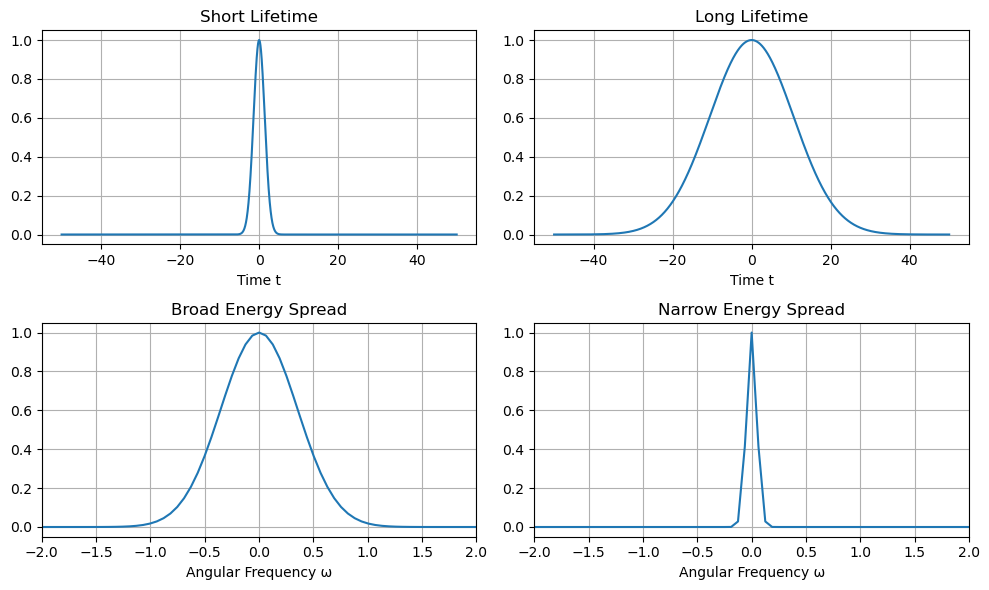

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Time grid
N = 4096
t_max = 50
t = np.linspace(-t_max, t_max, N)
dt = t[1] - t[0]

# Frequency grid (angular frequency ω)
omega = np.fft.fftshift(np.fft.fftfreq(N, d=dt)) * 2*np.pi

# Gaussian pulses in time (narrow vs wide)
def gaussian_t(t, sigma_t):
    return np.exp(-t**2/(2*sigma_t**2))

sigma_short = 2.0   # very short lifetime
sigma_long = 15.0   # long-lived state

psi_short = gaussian_t(t, sigma_short)
psi_long = gaussian_t(t, sigma_long)

# Fourier transform to frequency domain (normalized)
phi_short = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(psi_short))) * dt / np.sqrt(2*np.pi)
phi_long = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(psi_long))) * dt / np.sqrt(2*np.pi)

psi_short_prob = np.abs(psi_short)**2 / np.max(np.abs(psi_short)**2)
psi_long_prob = np.abs(psi_long)**2 / np.max(np.abs(psi_long)**2)
phi_short_prob = np.abs(phi_short)**2 / np.max(np.abs(phi_short)**2)
phi_long_prob = np.abs(phi_long)**2 / np.max(np.abs(phi_long)**2)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(10,6))

axes[0,0].plot(t, psi_short_prob)
axes[0,0].set_title("Short Lifetime")
axes[0,0].set_xlabel("Time t")
axes[0,0].grid(True)

axes[0,1].plot(t, psi_long_prob)
axes[0,1].set_title("Long Lifetime")
axes[0,1].set_xlabel("Time t")
axes[0,1].grid(True)

axes[1,0].plot(omega, phi_short_prob)
axes[1,0].set_title("Broad Energy Spread")
axes[1,0].set_xlabel("Angular Frequency ω")
axes[1,0].set_xlim(-2,2)
axes[1,0].grid(True)

axes[1,1].plot(omega, phi_long_prob)
axes[1,1].set_title("Narrow Energy Spread")
axes[1,1].set_xlabel("Angular Frequency ω")
axes[1,1].set_xlim(-2,2)
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.3.4 Real Momentum vs Heisenberg Momentum Spread

Students often ask:

**“If a particle has some actual momentum, why do we talk about momentum uncertainty from Heisenberg? Are they the same thing?”**

---

### The Real (Mean) Momentum

- Every particle may have an **average or mean momentum** $\langle p \rangle$.  
- For example, a moving electron might have $\langle p \rangle = 10^{-24}\ \text{kg·m/s}$, corresponding to a well-defined average velocity.  

Even in quantum mechanics, this mean momentum is just as "real" as in classical physics — it tells you the average motion of many identically prepared particles.

---

### The Momentum Spread (Uncertainty)

The **Heisenberg uncertainty principle** does **not** say that the particle has no real momentum.  

Instead, it sets a limit on how sharply we can define it **at the same time** as the position:

$$
\Delta x \, \Delta p \gtrsim \frac{\hbar}{2}
$$

- $\Delta p$ is the **spread** of momentum values you would find if you repeated the same measurement many times on identically prepared particles.  
- A particle can have a well-defined mean momentum **and** still have some spread in individual measurements.

---

### Well-Defined vs. Smeared-Out Momentum

- **Classical-like limit**: If the wave packet is very broad in $x$ ($\Delta x$ large), then $\Delta p$ can be extremely small → momentum is **almost perfectly defined**, as in classical physics.  
- **Quantum limit**: If we force the particle to be very localized ($\Delta x$ small), many $k$ components are needed → momentum values are **smeared out**.

---

### Why and When Do We Compare Them?

We often **compare** the Heisenberg momentum spread $\Delta p$ to the **mean momentum** $\langle p \rangle$ to judge whether:

1. **Classical behavior** is a good approximation:  
   If $\Delta p \ll \langle p \rangle$, the particle behaves like it has a well-defined trajectory.  

2. **Quantum effects** dominate:  
   If $\Delta p$ is comparable to or larger than $\langle p \rangle$, the particle’s motion is strongly affected by quantum uncertainty.

Example:  
- In the **double-slit experiment**, we compare $\Delta p_x$ (from localizing the particle to a slit) to the momentum spacing between fringes.  
- If $\Delta p_x$ becomes comparable, the interference pattern is destroyed.

---

### Key Concepts

- **Real momentum**: The average, classical-like motion of the particle.  
- **Heisenberg momentum spread**: The unavoidable quantum "fuzziness" around that mean.  
- Classical physics works when the spread is negligible compared to the mean; quantum effects dominate when it is not.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.3.5 Summary

- The uncertainty principle is a **direct consequence of wave-packet behavior**.
- $\Delta x \, \Delta p \gtrsim \hbar$ — you cannot know both perfectly.
- This principle lets us estimate ground-state energies and predict energy broadening.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">